In [1]:
import torchvision
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageShow 

In [2]:
# Import autoencoder utility tools
from MNIST.data.parser import transform, output_to_image
from MNIST.models.ae import AutoEncoder, latent_dims

In [3]:
interpolation_length = 10

In [4]:
# Initialise networks
autoencoder = AutoEncoder()
autoencoder.load_state_dict(torch.load('../models/autoencoder_v1/checkpoint_epoch_20.pt', map_location='cpu'))
encoder = autoencoder.encoder
decoder = autoencoder.decoder

In [8]:
# Download mnist data
inference_data = torchvision.datasets.MNIST('../data', download=True, transform=transform)

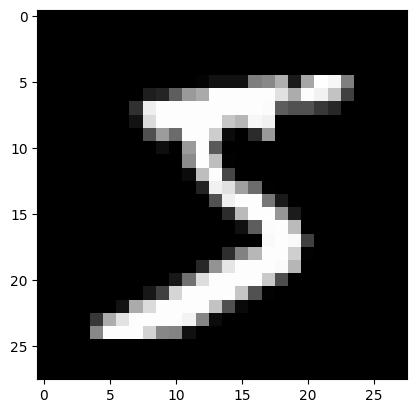

In [9]:
# Gather two mnist images
image_1 = inference_data[0][0] # 1x28x28 
image_2 = inference_data[1][0] # 1x28x28
plt.imshow(image_1.permute(1, 2, 0), cmap='gray')

In [10]:
# Convert images to b, c, w, h form
image_1 = torch.reshape(image_1, (1, 1, 28, 28))
image_2 = torch.reshape(image_2, (1, 1, 28, 28))

In [11]:
# Encode both into latent tensors
latent_1, latent_2 = encoder(image_1), encoder(image_2)

In [12]:
# Interpolate latent tensors
batch = np.empty((interpolation_length, latent_dims))
with torch.inference_mode():
    for i in range(interpolation_length):
        batch[i] = latent_1 + (i*(latent_2-latent_1))/interpolation_length-1
batch

array([[ 3.39858413e-01, -7.41680920e-01,  9.82642174e-04, ...,
        -8.73720586e-01, -2.80229151e-01, -3.04702497e+00],
       [ 1.99266315e-01, -8.51215959e-01,  1.01582289e-01, ...,
        -9.75613177e-01, -3.13077331e-01, -2.96112108e+00],
       [ 5.86743355e-02, -9.60750937e-01,  2.02181816e-01, ...,
        -1.07750571e+00, -3.45925570e-01, -2.87521744e+00],
       ...,
       [-6.44285977e-01, -1.50842595e+00,  7.05179930e-01, ...,
        -1.58696866e+00, -5.10166526e-01, -2.44569826e+00],
       [-7.84878016e-01, -1.61796093e+00,  8.05779457e-01, ...,
        -1.68886137e+00, -5.43014705e-01, -2.35979462e+00],
       [-9.25469995e-01, -1.72749591e+00,  9.06379104e-01, ...,
        -1.79075384e+00, -5.75862885e-01, -2.27389050e+00]],
      shape=(10, 512))

In [13]:
# Decode into interpolation images (normalised)
formatted_interpolation = torch.from_numpy(batch)
output = decoder(formatted_interpolation.to(torch.float32))
output.shape

torch.Size([10, 1, 28, 28])

In [16]:
# Convert to 0, 255
images = output_to_image(output)

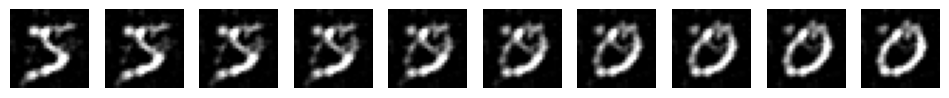

In [17]:
# Plot output in 1, 10 figure
fig, axes = plt.subplots(1, 10, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(images[i].permute(1, 2, 0), cmap='gray')
    ax.axis('off')

## Observations
In the above interpolation I can see the transition from a 5 to a 0. Honestly not much looks wrong with it... Either I'm missing a key detail or MNIST is not a good example for showing the lack of meaning within latent dimensions. 

After a brief AI chat, I have reached the conclusion that there is no continuity between these two encodings. This means that if sampling was attempted, most points would be gibberish and not interpretable digits.